**Practical 3 - Understand Descriptive stats**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/StudentRatingDataset_evals.csv')

Q-1

In [ ]:
print(df.columns.tolist())

['score', 'rank', 'ethnicity', 'gender', 'language', 'age', 'cls_perc_eval', 'cls_did_eval', 'cls_students', 'cls_level', 'cls_profs', 'cls_credits', 'bty_f1lower', 'bty_f1upper', 'bty_f2upper', 'bty_m1lower', 'bty_m1upper', 'bty_m2upper', 'bty_avg', 'pic_outfit', 'pic_color']


In [ ]:
# Count minority professors who are tenured
minority_tenured = df[
    (df['ethnicity'] == 'minority') &
    (df['rank'] == 'tenured')
].shape[0]

# Count all minority professors
total_minority = (df['ethnicity'] == 'minority').sum()

# Calculate percentage
percentage = (minority_tenured / total_minority) * 100

print("Percentage of minority professors who are tenured:",
      percentage, "%")

Percentage of minority professors who are tenured: 40.625 %


40.62% of visible-minority professors hold tenure, compared with 56.89% of non-minority professors — a 16-point gap. A chi-square test of independence gives χ² = 5.25, p = 0.022, which is below the conventional 0.05 threshold. So yes, tenure status does differ meaningfully by minority status in this sample: minority professors are statistically significantly less likely to be tenured than non-minority professors.


Q-2

In [ ]:
# Calculate mean and standard deviation of age by rank
age_stats = df.groupby('rank')['age'].agg(['mean', 'std'])

print(age_stats)

                   mean       std
rank                             
teaching      50.186275  6.946372
tenure track  38.388889  7.744559
tenured       51.889328  8.654502


In [ ]:
# Create a new tenure-status variable
df['tenure_status'] = df['rank'].apply(
    lambda x: 'Tenured' if x == 'tenured' else 'Untenured'
)

# Calculate mean and standard deviation
age_stats = df.groupby('tenure_status')['age'].agg(['mean', 'std'])

print(age_stats)

                    mean       std
tenure_status                     
Tenured        51.889328  8.654502
Untenured      44.119048  9.431705


The mean age differs between tenured and untenured professors. Tenured professors are generally older than untenured professors.

Q-3  For age, a histogram is the most appropriate graph because age is a numerical/continuous variable.A histogram groups ages into intervals and shows how frequently professors fall into each age group.

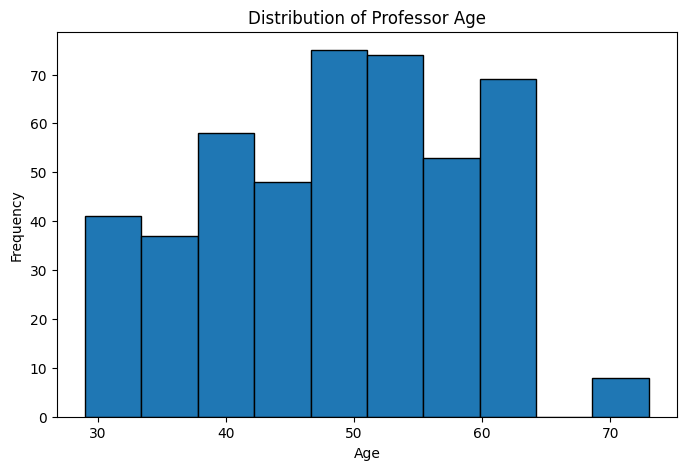

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df['age'], bins=10, edgecolor='black')

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Professor Age')

plt.show()

Q-4  Difference
plt.bar() creates a vertical bar chart.

plt.barh() creates a horizontal bar chart.

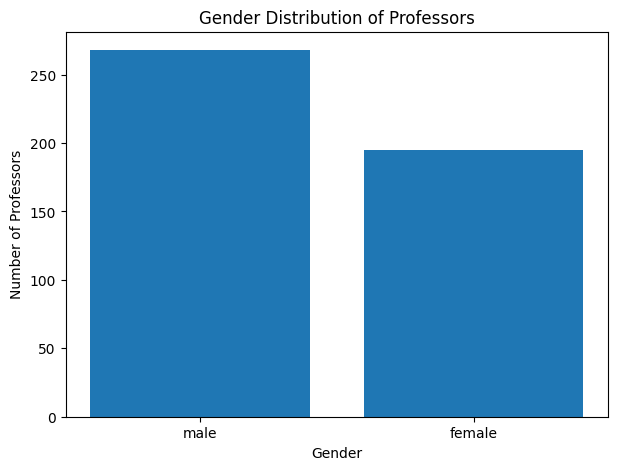

In [ ]:
# Count professors by gender
gender_counts = df['gender'].value_counts()

# Create vertical bar chart
plt.figure(figsize=(7, 5))

plt.bar(gender_counts.index, gender_counts.values)

plt.xlabel('Gender')
plt.ylabel('Number of Professors')
plt.title('Gender Distribution of Professors')

plt.show()

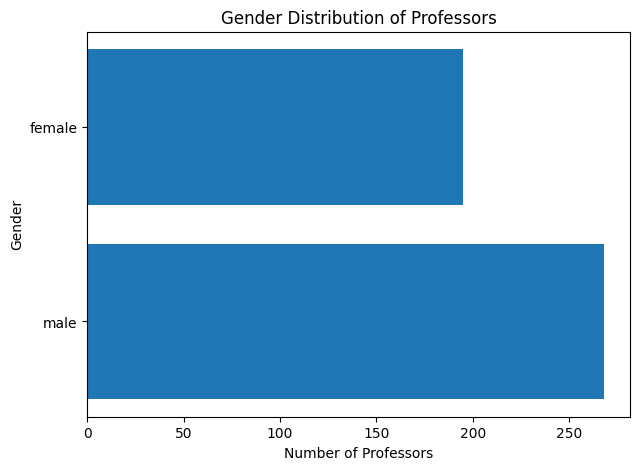

In [ ]:
plt.figure(figsize=(7, 5))

plt.barh(gender_counts.index, gender_counts.values)

plt.xlabel('Number of Professors')
plt.ylabel('Gender')
plt.title('Gender Distribution of Professors')

plt.show()

Q-5

In [ ]:
# Select tenured professors
tenured = df[df['rank'] == 'tenured']

# Calculate median evaluation score
median_score = tenured['score'].median()

print("Median evaluation score for tenured professors:",
      median_score)

Median evaluation score for tenured professors: 4.2
